#### Milestone 1

In [83]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [84]:
df = pd.read_csv("netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [85]:
df.shape

(8807, 12)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [87]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [88]:
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['column', 'missing_count']


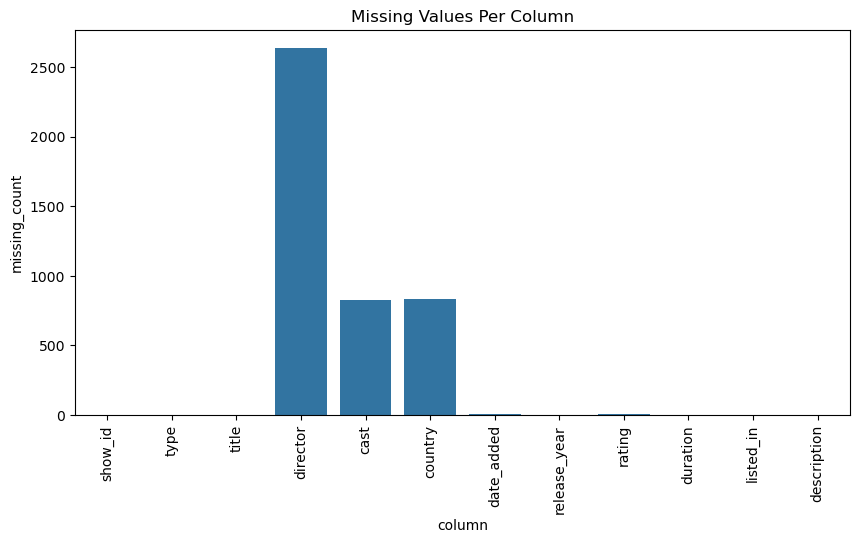

In [89]:

plt.figure(figsize=(10,5))
sns.barplot(data=missing_df, x='column', y='missing_count')
plt.xticks(rotation=90)
plt.title("Missing Values Per Column")
plt.show()


In [90]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [91]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('No Data')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])


In [92]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [93]:
df = df.dropna(subset=['date_added'])

In [94]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month


In [95]:
df['date_added'].dtype

dtype('<M8[ns]')

In [96]:
df[df.duplicated()]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added


In [97]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

In [98]:
df.to_csv("cleaned_netflix_data.csv", index=False)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No Data,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,No Data,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


#### Milestone 2 

In [99]:
data = pd.read_csv("cleaned_netflix_data.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",No Data,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,No Data,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9


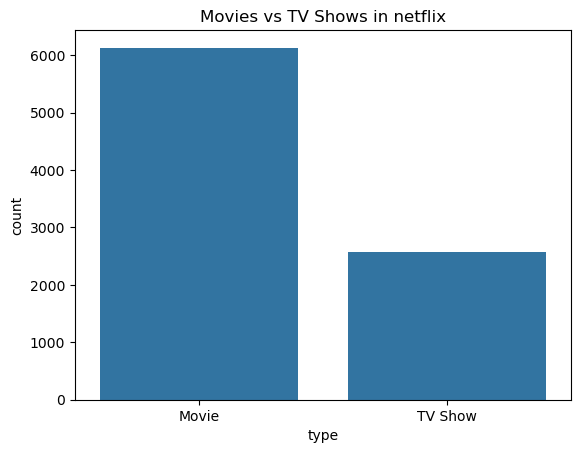

<Figure size 1200x600 with 0 Axes>

In [100]:
sns.countplot(data=data , x = 'type')
plt.title("Movies vs TV Shows in netflix")
plt.figure(figsize = (12,6))
plt.show()

In [101]:
'''
Observation:
Movies dominate the platform compared to TV Shows.

Explanation:
Netflix content is heavily movie-focused. TV Shows are growing but still significantly
fewer than movies.'''

'\nObservation:\nMovies dominate the platform compared to TV Shows.\n\nExplanation:\nNetflix content is heavily movie-focused. TV Shows are growing but still significantly\nfewer than movies.'

In [102]:
data['rating'].value_counts()

rating
TV-MA       3187
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [103]:
'''TV-MA
Mature Audience Only.
Suitable for adults. May contain strong language, violence, or sexual content.

TV-14
Parents strongly cautioned.
May not be suitable for children under 14.

TV-PG
Parental guidance suggested.
Some material may not be suitable for younger children.

TV-Y7
Directed to children age 7 and above.
May include mild fantasy violence.

TV-Y
Suitable for all children.

TV-G
General audience. Suitable for all ages.

TV-Y7-FV
TV-Y7 with fantasy violence.

R
Restricted.
Under 17 requires accompanying parent or adult guardian.

PG-13
Parents strongly cautioned.
Some material may be inappropriate for children under 13.

PG
Parental guidance suggested.

G
General audience. Suitable for all ages.

NC-17
No one 17 and under admitted.
Adults only.

NR
Not Rated.
No official rating assigned.

UR
Unrated version.
Typically contains additional or unreviewed content.'''

'TV-MA\nMature Audience Only.\nSuitable for adults. May contain strong language, violence, or sexual content.\n\nTV-14\nParents strongly cautioned.\nMay not be suitable for children under 14.\n\nTV-PG\nParental guidance suggested.\nSome material may not be suitable for younger children.\n\nTV-Y7\nDirected to children age 7 and above.\nMay include mild fantasy violence.\n\nTV-Y\nSuitable for all children.\n\nTV-G\nGeneral audience. Suitable for all ages.\n\nTV-Y7-FV\nTV-Y7 with fantasy violence.\n\nR\nRestricted.\nUnder 17 requires accompanying parent or adult guardian.\n\nPG-13\nParents strongly cautioned.\nSome material may be inappropriate for children under 13.\n\nPG\nParental guidance suggested.\n\nG\nGeneral audience. Suitable for all ages.\n\nNC-17\nNo one 17 and under admitted.\nAdults only.\n\nNR\nNot Rated.\nNo official rating assigned.\n\nUR\nUnrated version.\nTypically contains additional or unreviewed content.'

In [104]:
data = data[~data['rating'].str.contains('min', na = False)]


In [105]:
data['rating'].value_counts()
#removed 74 min,84 min,66 min because they are not ratings. they are duration.
#even those are only 3 values so if we remove them it will not affect our analysis much.

rating
TV-MA       3187
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64

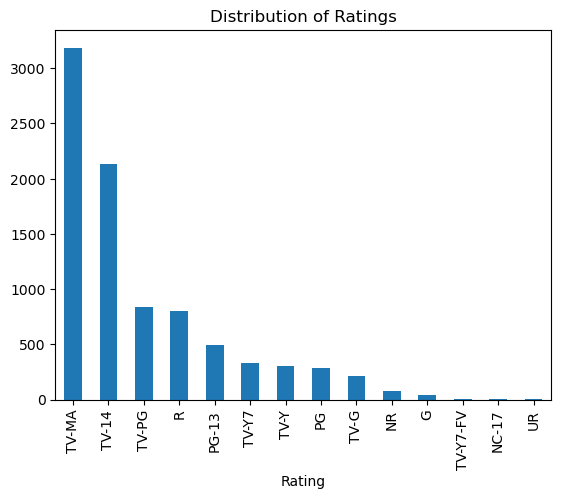

In [106]:
data['rating'].value_counts().plot(kind='bar')
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.show()

In [107]:
'''
Observation: 
TV-MA and TV-14 ratings dominate the dataset .'''

'\nObservation: \nTV-MA and TV-14 ratings dominate the dataset .'

In [108]:

data['decade'] = (data['release_year'] // 10) * 10
data['decade'].value_counts().sort_index()

decade
1920       1
1940      15
1950      11
1960      24
1970      69
1980     128
1990     271
2000     804
2010    5838
2020    1545
Name: count, dtype: int64

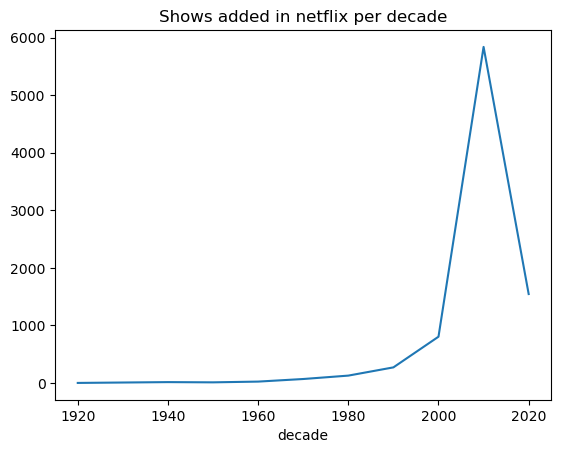

In [109]:
data['decade'].value_counts().sort_index().plot(kind='line')
plt.title("Shows added in netflix per decade")
plt.xlabel("decade")
plt.show()

In [110]:
'''observation:
Movies and shows(More no.of content) show sharp growth in the 2010s.'''

'observation:\nMovies and shows(More no.of content) show sharp growth in the 2010s.'

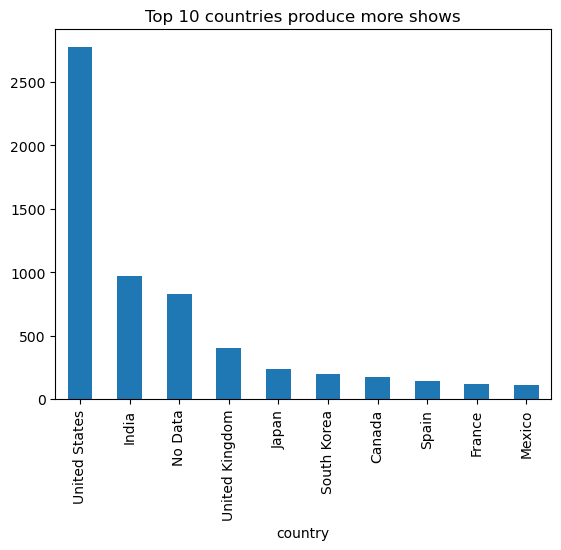

In [111]:
data['country'].value_counts().head(10).plot(kind = 'bar')
plt.title("Top 10 countries produce more shows")
plt.show()

Text(0.5, 1.0, "Top 10 countries wthout 'No Data'")

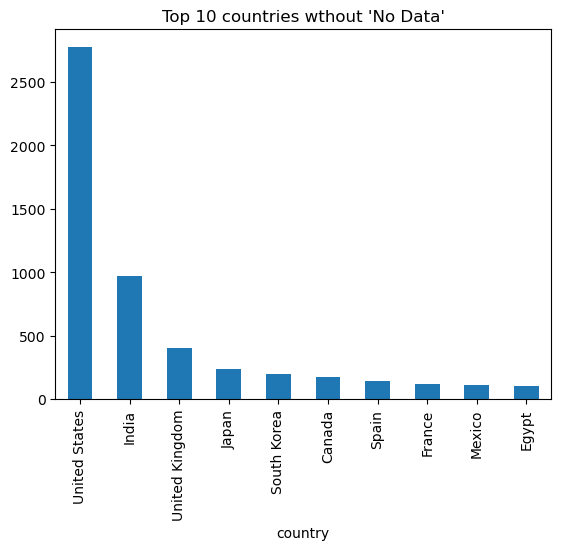

In [112]:
data[data['country'] != 'No Data']['country'].value_counts().head(10).plot(kind = 'bar')
plt.title("Top 10 countries wthout 'No Data'")

In [113]:
'''Observation:
United States produces the highest number of titles, followed by India and the United Kingdom.

Explanation:
The US is the dominant content contributor on Netflix. 
India is the second-largest contributor, indicating strong regional expansion 
and localization strategy.'''

'Observation:\nUnited States produces the highest number of titles, followed by India and the United Kingdom.\n\nExplanation:\nThe US is the dominant content contributor on Netflix. \nIndia is the second-largest contributor, indicating strong regional expansion \nand localization strategy.'

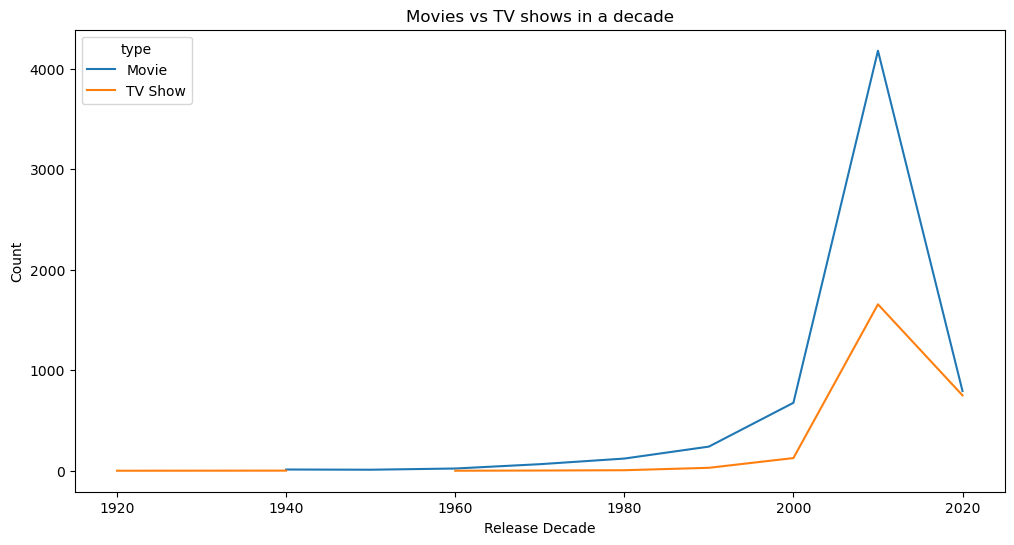

In [114]:
year_type = data.groupby(['decade', 'type']).size().unstack()
year_type.plot(figsize=(12,6))
plt.title("Movies vs TV shows in a decade")
plt.ylabel("Count")
plt.xlabel("Release Decade")
plt.show()

In [115]:
'''
Observation:
Content volume increased sharply after 2000, especially during the 2010s. 
Movies consistently outnumber TV Shows across all decades.

Explanation:
The 2010s mark the rapid expansion phase of Netflix. 
The growth spike reflects platform scaling rather than a genre or type shift.
'''

'\nObservation:\nContent volume increased sharply after 2000, especially during the 2010s. \nMovies consistently outnumber TV Shows across all decades.\n\nExplanation:\nThe 2010s mark the rapid expansion phase of Netflix. \nThe growth spike reflects platform scaling rather than a genre or type shift.\n'

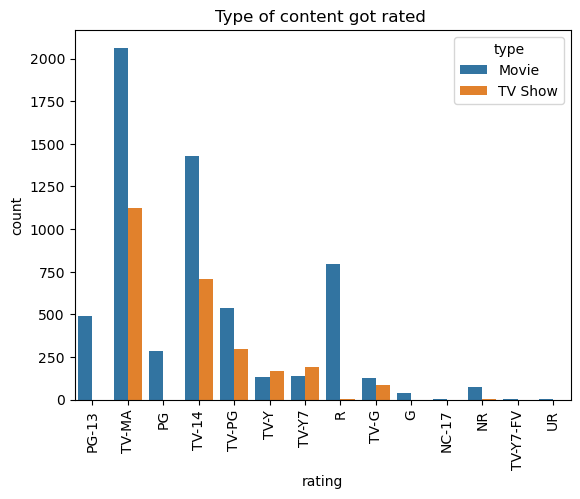

In [116]:
sns.countplot(data=data, x='rating', hue = 'type')
plt.title("Type of content got rated ")
plt.xticks(rotation = 90)
plt.show()

In [117]:
'''
Observation:
TV-MA and TV-14 ratings dominate the dataset.
Explanation:
Most Netflix content targets mature and young adult audiences.
 Family and kids categories exist but represent a smaller portion of total content.'''

'\nObservation:\nTV-MA and TV-14 ratings dominate the dataset.\nExplanation:\nMost Netflix content targets mature and young adult audiences.\n Family and kids categories exist but represent a smaller portion of total content.'

In [118]:
data_analyse = data.copy()
data_analyse['genre'] = data_analyse['listed_in'].str.split(',')
data_analyse = data_analyse.explode('genre')
data_analyse['genre'] = data_analyse['genre'].str.strip()

genre_type = pd.crosstab(data_analyse['genre'],data_analyse['type'])

top_genre = data_analyse['genre'].value_counts().head(20).index

genre_type.loc[top_genre]

type,Movie,TV Show
genre,,
International Movies,2752,0
Dramas,2427,0
Comedies,1674,0
International TV Shows,0,1328
Documentaries,869,0
Action & Adventure,859,0
Independent Movies,756,0
TV Dramas,0,739
Children & Family Movies,641,0


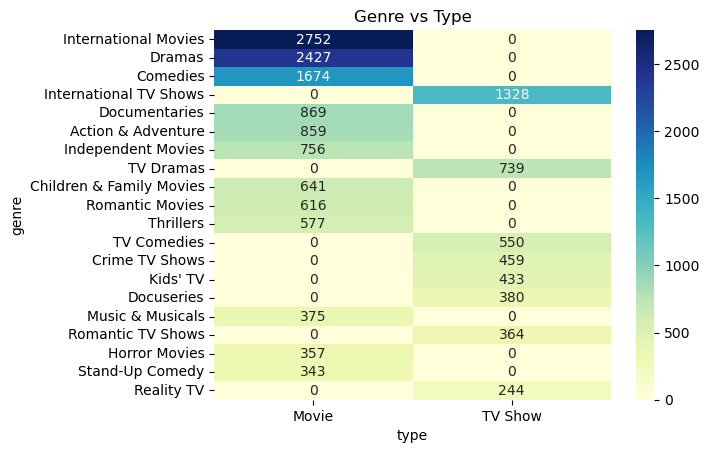

In [119]:
top_20 = data_analyse['genre'].value_counts().head(20).index
sns.heatmap(genre_type.loc[top_20], annot=True, fmt='d', cmap='YlGnBu')
plt.title("Genre vs Type")
plt.show()

In [120]:
''''
Observation:
International Movies, Dramas, and Comedies dominate Movies.
International TV Shows and TV Dramas dominate TV Shows.

Explanation:
Movie content is diversified but strongly centered around drama and international categories.
TV Shows lean heavily toward serialized drama and international formats.'''

"'\nObservation:\nInternational Movies, Dramas, and Comedies dominate Movies.\nInternational TV Shows and TV Dramas dominate TV Shows.\n\nExplanation:\nMovie content is diversified but strongly centered around drama and international categories.\nTV Shows lean heavily toward serialized drama and international formats."

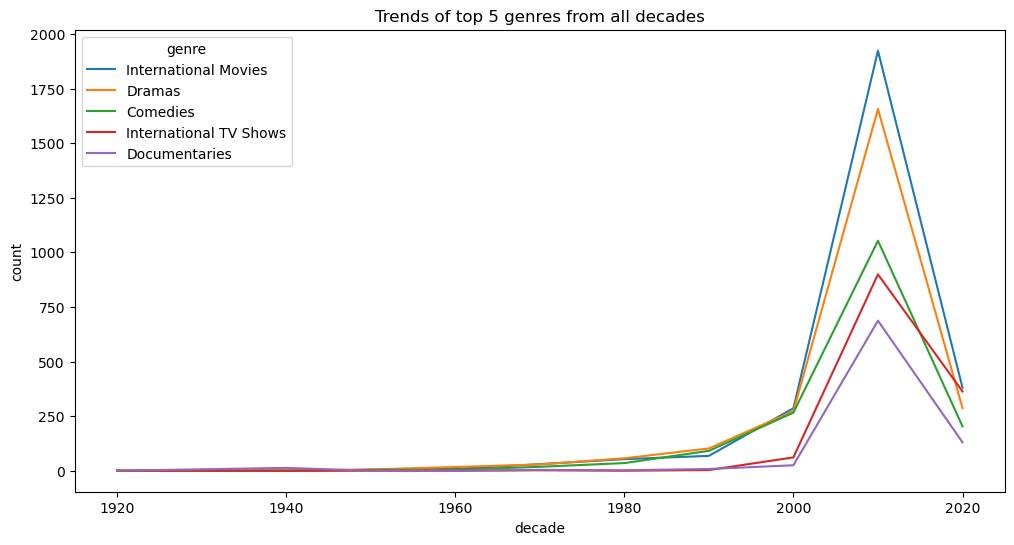

In [121]:
data_analyse['decade'] = (data_analyse['release_year'] // 10) * 10
genre_year = pd.crosstab(data_analyse['decade'],data_analyse['genre'])
top_5 = data_analyse['genre'].value_counts().head(5).index
genre_year[top_5].plot(figsize=(12,6))
plt.title("Trends of top 5 genres from all decades")
plt.xlabel('decade')
plt.xticks(rotation = 0)
plt.ylabel('count')
plt.show()

In [122]:
'''Observation:
All top genres show sharp growth in the 2010s.

Explanation:
The rise reflects overall content expansion rather than a sudden change in audience interest. 
Platform growth drives genre volume increase'''

'Observation:\nAll top genres show sharp growth in the 2010s.\n\nExplanation:\nThe rise reflects overall content expansion rather than a sudden change in audience interest. \nPlatform growth drives genre volume increase'

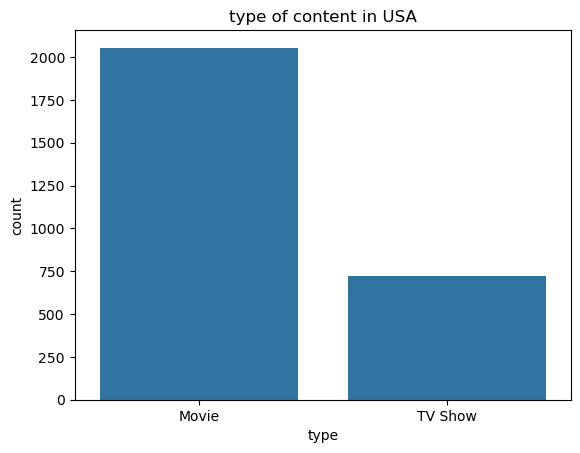

In [123]:
sns.countplot(data=data[data['country'] == 'United States'], x='type')
plt.title("type of content in USA")
plt.xticks(rotation = 0)
plt.show()

In [124]:
usa = data[data['country'] == 'United States']
usa_genre = usa['listed_in'].str.split(',').explode().str.strip()
usa_Gcount = usa_genre.value_counts()
usa_Gcount.head(10)

listed_in
Dramas                      591
Comedies                    524
Documentaries               411
Independent Movies          302
Children & Family Movies    272
Action & Adventure          249
TV Comedies                 217
Stand-Up Comedy             215
Thrillers                   193
TV Dramas                   175
Name: count, dtype: int64

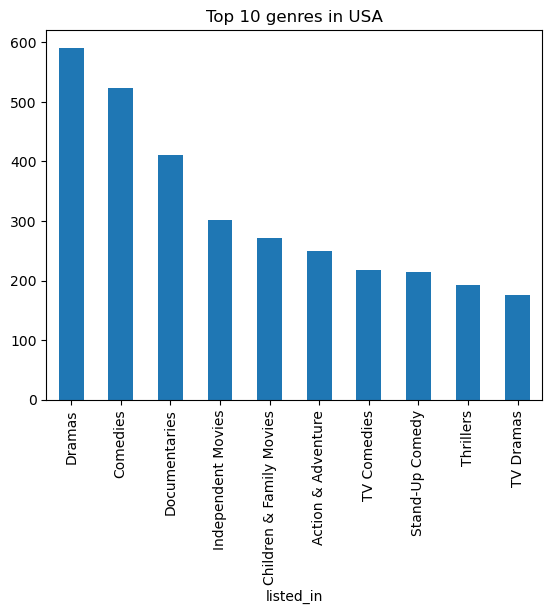

In [125]:
usa_Gcount.head(10).plot(kind='bar')
plt.title("Top 10 genres in USA")
plt.show()

In [126]:
'''Observation:
Dramas, Comedies, and Documentaries are the top genres in the United States.

Explanation:
US content emphasizes narrative-driven and entertainment-focused categories, 
with strong representation in documentary and independent films.'''

'Observation:\nDramas, Comedies, and Documentaries are the top genres in the United States.\n\nExplanation:\nUS content emphasizes narrative-driven and entertainment-focused categories, \nwith strong representation in documentary and independent films.'

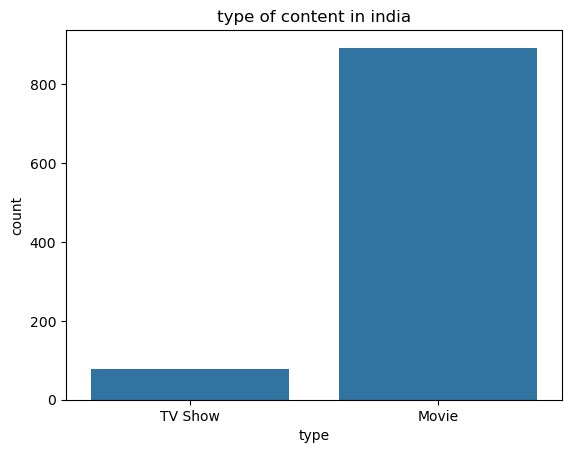

In [127]:
sns.countplot(data=data[data['country'] == 'India'], x='type')
plt.title("type of content in india")
plt.xticks(rotation = 0)
plt.show()

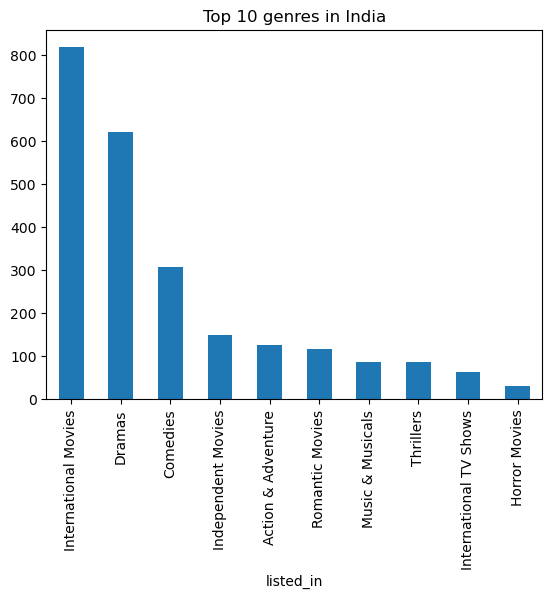

In [128]:
india = data[data['country'] == 'India']
india_genre = india['listed_in'].str.split(',').explode().str.strip()
india_Gcount = india_genre.value_counts().head(10)
india_Gcount.plot(kind='bar')
plt.title("Top 10 genres in India")
plt.show()

In [129]:
'''Observation:
International Movies and Dramas dominate Indian-listed content.

Explanation:
Netflix offers a strong presence of drama and internationally categorized films in India. 
'''

'Observation:\nInternational Movies and Dramas dominate Indian-listed content.\n\nExplanation:\nNetflix offers a strong presence of drama and internationally categorized films in India. \n'

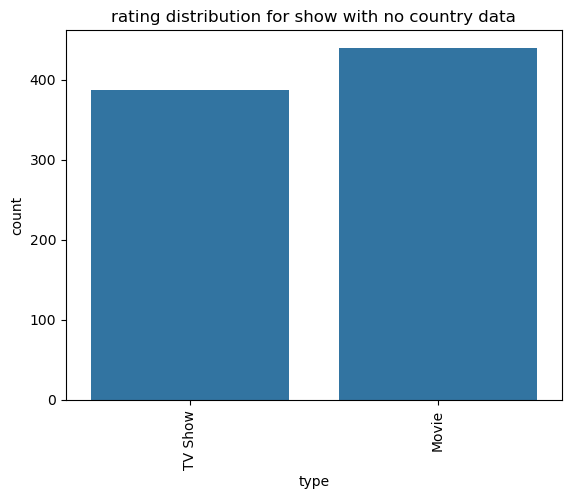

In [130]:
sns.countplot(data=data[data['country'] == 'No Data'], x='type')
plt.title("rating distribution for show with no country data")
plt.xticks(rotation = 90)
plt.show()

In [131]:
'''Observation:
No Country data covers mostly Movies content rather than Tv Shows.
'''

'Observation:\nNo Country data covers mostly Movies content rather than Tv Shows.\n'

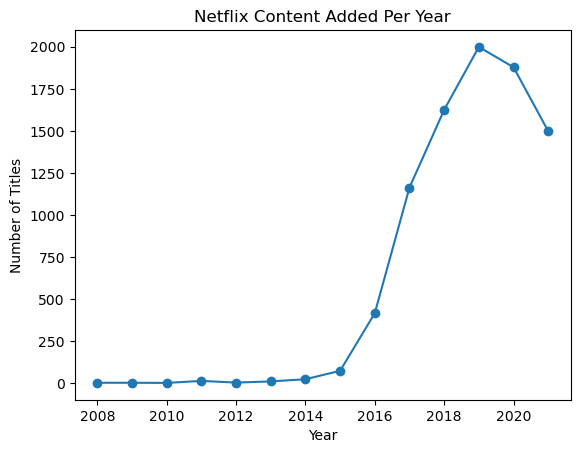

In [132]:
data['date_added'] = pd.to_datetime(data['date_added'])
data['year_added'] = data['date_added'].dt.year

content_growth = data['year_added'].value_counts().sort_index()

content_growth.plot(kind='line', marker='o')
plt.title("Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

In [133]:
'''observation : Netflix content expansion accelerated after 2015.'''

'observation : Netflix content expansion accelerated after 2015.'

In [134]:
movies = data[data['type']=='Movie'].copy()
movies['duration_int'] = movies['duration'].str.replace(' min','').astype(int)

In [135]:
def length_category(x):
    if x < 60:
        return "Short"
    elif x <= 120:
        return "Medium"
    else:
        return "Long"

movies['length_category'] = movies['duration_int'].apply(length_category)

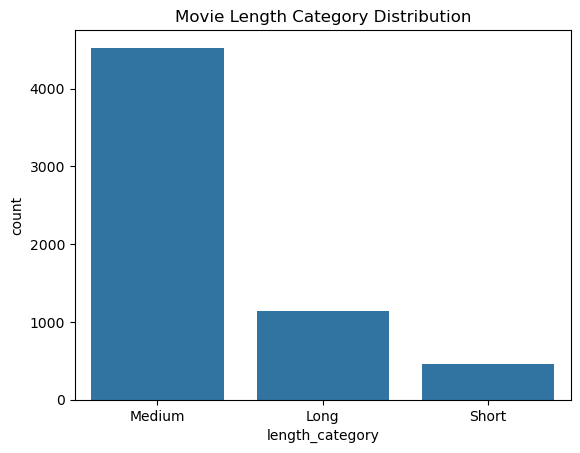

In [136]:
sns.countplot(data=movies, x='length_category')
plt.title("Movie Length Category Distribution")
plt.show()

In [137]:
'''observation: Most Netflix movies fall in medium duration (60–120 minutes).'''

'observation: Most Netflix movies fall in medium duration (60–120 minutes).'

In [138]:
tv = data[data['type']=='TV Show'].copy()

tv['seasons'] = tv['duration'].str.replace(' Seasons','').str.replace(' Season','')
tv['seasons'] = tv['seasons'].astype(int)

In [139]:
def season_category(x):
    if x == 1:
        return "Single Season"
    elif x <= 3:
        return "Limited Series"
    else:
        return "Multi-season"

tv['season_category'] = tv['seasons'].apply(season_category)
print(tv['season_category'].value_counts())

season_category
Single Season     1791
Limited Series     562
Multi-season       225
Name: count, dtype: int64


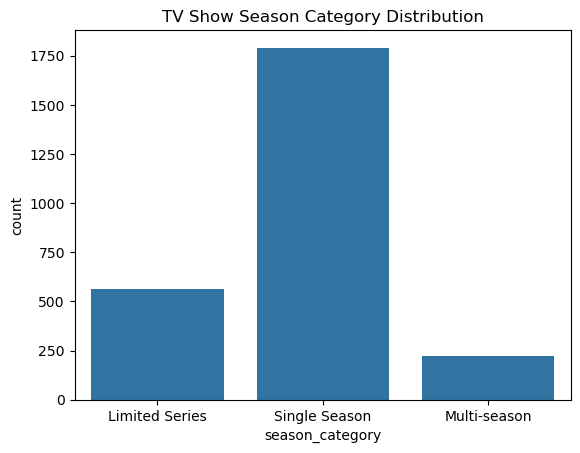

In [140]:
sns.countplot(data=tv, x='season_category')
plt.title("TV Show Season Category Distribution")
plt.show()

#### Milestone 3

In [141]:
from sklearn.preprocessing import LabelEncoder

data_model = data.copy()

le_type = LabelEncoder()
le_rating = LabelEncoder()

data_model['type_enc'] = le_type.fit_transform(data_model['type'])
data_model['rating_enc'] = le_rating.fit_transform(data_model['rating'])

In [142]:
data_model['main_genre'] = data_model['listed_in'].apply(
    lambda x: str(x).split(',')[0].strip())
genre_dummies = pd.get_dummies(data_model['main_genre'], prefix='genre')
data_model = pd.concat([data_model, genre_dummies], axis=1)

In [143]:
data_model['main_country'] = data_model['country'].apply(lambda x: str(x).split(',')[0].strip())
le_country = LabelEncoder()
data_model['country_enc'] = le_country.fit_transform(data_model['main_country'])


In [144]:
import numpy as np

def clean_duration(x):
    x = str(x)
    try:
        if "min" in x:
            return int(x.split()[0])
        elif "Season" in x:
            return int(x.split()[0])*10
        else:
            return None
    except:
        return None

data_model['duration_clean'] = data_model['duration'].apply(clean_duration)

In [145]:
from datetime import datetime
current_year = datetime.now().year
data_model['content_age'] = current_year - data_model['release_year']

In [146]:
data_model = data_model.dropna(subset=['duration_clean', 'rating_enc', 'country_enc'])

In [147]:
from sklearn.cluster import KMeans
import joblib
cluster_features = data_model[
    ['rating_enc', 'duration_clean', 'content_age', 'country_enc']
    ].dropna()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(cluster_scaled)
data_model.loc[cluster_features.index, 'cluster'] = clusters

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler,"scaler.pkl")
data_model.to_csv("final_clustered_data.csv", index=False)

In [148]:
data_model.groupby('cluster')[[
    'rating_enc', 'duration_clean', 'content_age', 'country_enc'
]].mean()

,rating_enc,duration_clean,content_age,country_enc
cluster,,,,
0.0,8.143732,42.015172,8.947565,69.566409
1.0,7.155732,96.125451,10.235040,26.936554
2.0,4.665893,103.363689,12.732599,77.717517
3.0,5.618625,113.164080,41.678492,58.758315


In [149]:
pd.crosstab(data_model['cluster'], data_model['type'])

type,Movie,TV Show
cluster,,
0.0,1599,2158
1.0,2404,370
2.0,1696,28
3.0,429,22


In [150]:
cluster_summary = data_model.groupby('cluster')[[
    'duration_clean', 'content_age'
]].mean()

type_distribution = pd.crosstab(data_model['cluster'], data_model['type'])

print(cluster_summary)
print(type_distribution)

         duration_clean  content_age
cluster                             
0.0           42.015172     8.947565
1.0           96.125451    10.235040
2.0          103.363689    12.732599
3.0          113.164080    41.678492
type     Movie  TV Show
cluster                
0.0       1599     2158
1.0       2404      370
2.0       1696       28
3.0        429       22


In [151]:
from sklearn.metrics import silhouette_score

score = silhouette_score(cluster_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.32060436455699565


In [152]:
print("Inertia:", kmeans.inertia_)

Inertia: 15849.333902315866


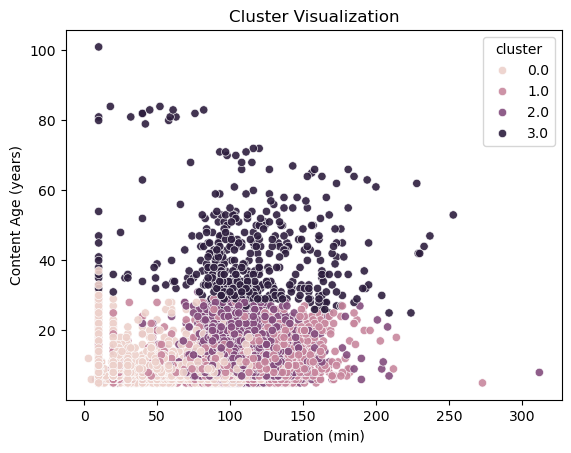

In [153]:
sns.scatterplot(
    data=data_model,
    x='duration_clean',
    y='content_age',
    hue='cluster',
    alpha=0.9
)
plt.title("Cluster Visualization")
plt.xlabel("Duration (min)")
plt.ylabel("Content Age (years)")
plt.show()

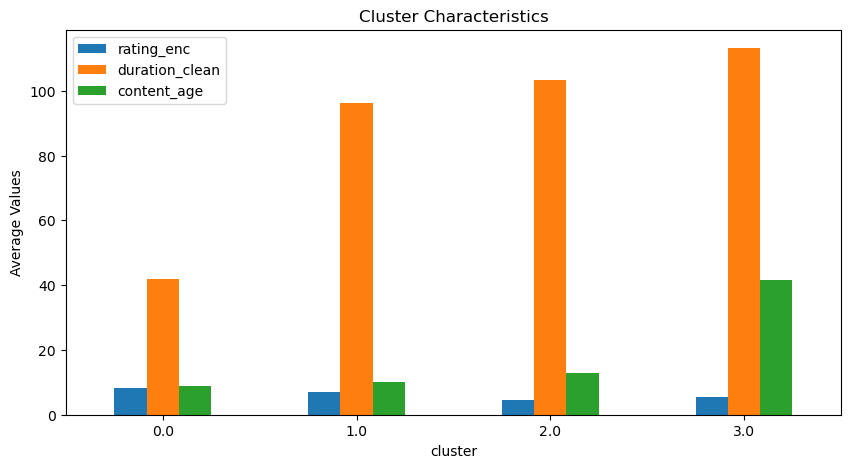

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_profile = data_model.groupby('cluster')[[
    'rating_enc', 'duration_clean', 'content_age'
]].mean()

cluster_profile.plot(kind='bar', figsize=(10,5))
plt.title("Cluster Characteristics")
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.show()

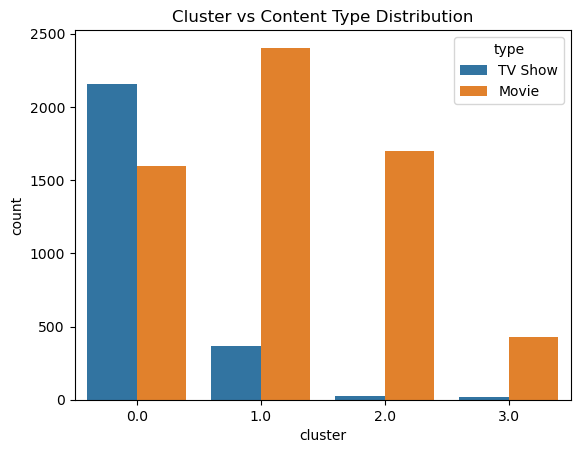

In [155]:
sns.countplot(data=data_model, x='cluster', hue='type')
plt.title("Cluster vs Content Type Distribution")
plt.show()

In [156]:
data_model['combined_features'] = (
    data_model['listed_in'].fillna('') + " " +
    data_model['description'].fillna('')
)

In [157]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(data_model['combined_features'])

In [158]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [159]:
indices = pd.Series(data_model.index, index=data_model['title']).drop_duplicates()

In [160]:
use_cols = ['title', 'type', 'listed_in', 'country', 'release_year', 'rating']

In [161]:
def recommend(query, top_n=5):
    query = query.lower()

    # CASE 1 → Title match
    if query in indices.index.str.lower():
        idx = indices[indices.index.str.lower() == query].values[0]

        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

        sim_scores = sim_scores[1:top_n+1]
        movie_indices = [i[0] for i in sim_scores]

        selected = data_model[use_cols].iloc[[idx]]
        recommendations = data_model[use_cols].iloc[movie_indices]

        return selected, recommendations

    # CASE 2 → Genre search
    else:
        genre_results = data_model[
        data_model['listed_in'].str.lower().apply(
        lambda x: any(query in g.strip() for g in x.split(','))
        )]

        if genre_results.empty:
            return None, None

        selected = genre_results.iloc[[0]]
        recommendations = genre_results.iloc[1:]

        return selected, recommendations

In [162]:
selected, recs = recommend("Narcos")

print("=== SELECTED ===")
display(selected)

print("\n=== RECOMMENDATIONS ===")
display(recs)

=== SELECTED ===


,title,type,listed_in,country,release_year,rating
5305,Narcos,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas","United States, Colombia, Mexico",2017,TV-MA



=== RECOMMENDATIONS ===


,title,type,listed_in,country,release_year,rating
7409,Miss Dynamite,TV Show,"Crime TV Shows, International TV Shows, Spanis...",Mexico,2015,TV-14
2921,Narcos: Mexico,TV Show,"Crime TV Shows, TV Action & Adventure, TV Dramas","Mexico, United States",2020,TV-MA
6652,El Cartel 2,TV Show,"Crime TV Shows, International TV Shows, Spanis...",Colombia,2010,TV-MA
4750,El Chapo,TV Show,"Crime TV Shows, Spanish-Language TV Shows, TV ...","Mexico, United States",2018,TV-MA
2,Ganglands,TV Show,"Crime TV Shows, International TV Shows, TV Act...",No Data,2021,TV-MA


In [163]:
selected, recs = recommend("Comedy")

print("=== SELECTED ===")
display(selected)

print("\n=== RECOMMENDATIONS ===")
display(recs)

=== SELECTED ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,genre_TV Horror,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_Thrillers,main_country,country_enc,duration_clean,content_age,cluster,combined_features
278,s279,Movie,Lokillo: Nothing's the Same,Julián Gaviria,Lokillo Florez,Colombia,2021-08-12,2021,TV-MA,64 min,...,False,False,False,False,Colombia,14,64,5,1.0,"Stand-Up Comedy Through songs and puns, comedi..."



=== RECOMMENDATIONS ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,genre_TV Horror,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_Thrillers,main_country,country_enc,duration_clean,content_age,cluster,combined_features
359,s360,Movie,The Original Kings of Comedy,Spike Lee,"Steve Harvey, D.L. Hughley, Cedric the Enterta...",United States,2021-08-01,2000,R,111 min,...,False,False,False,False,United States,81,111,26,2.0,"Stand-Up Comedy Comedians Steve Harvey, Cedric..."
388,s389,TV Show,Plastic Cup Boyz: Laughing My Mask Off!,"Royale Watkins, Rich Schlansker","Joey Wells, Will 'Spank' Horton, Na'im Lynn",No Data,2021-07-27,2021,TV-MA,1 Season,...,False,False,False,False,No Data,51,10,5,0.0,"Stand-Up Comedy & Talk Shows, TV Comedies Come..."
400,s401,TV Show,Revelations: The Masters of the Universe: Reve...,Unknown,"Kevin Smith, Tiffany Smith, Robert David, Sara...",No Data,2021-07-23,2021,TV-PG,1 Season,...,False,False,False,False,No Data,51,10,5,0.0,"Anime Series, Stand-Up Comedy & Talk Shows Tak..."
475,s476,Movie,The Stand-Up,Daniel Růžička,"Iva Pazderková, Lukáš Pavlásek, Daniel Čech, P...",No Data,2021-07-10,2019,TV-MA,93 min,...,False,False,False,False,No Data,51,93,7,1.0,Stand-Up Comedy Members of the comedy group Na...
484,s485,Movie,Lee Su-geun: The Sense Coach,Kim Joo-hyung,Lee Su-geun,No Data,2021-07-09,2021,TV-G,46 min,...,False,False,False,False,No Data,51,46,5,0.0,Stand-Up Comedy Lee Su-geun's rise to Korean c...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7745,s7813,TV Show,Queens of Comedy,Unknown,Unknown,No Data,2018-05-01,2017,TV-MA,1 Season,...,False,False,False,False,No Data,51,10,9,0.0,"International TV Shows, Stand-Up Comedy & Talk..."
7746,s7814,TV Show,Queens vs. Kings,Unknown,"Varun Thakur, Anu Menon, Rahul Subramanian, Si...",No Data,2018-10-25,2018,TV-14,1 Season,...,False,False,False,False,No Data,51,10,8,0.0,"Stand-Up Comedy & Talk Shows, TV Comedies No ""..."
7837,s7909,TV Show,Russell Peters vs. the World,Unknown,Russell Peters,United States,2013-10-14,2013,NR,1 Season,...,False,False,False,False,United States,81,10,13,2.0,"Docuseries, Stand-Up Comedy & Talk Shows A fou..."
7838,s7910,Movie,Russell Peters: Notorious,Dave Higby,Russell Peters,United States,2013-10-14,2013,NR,72 min,...,False,False,False,False,United States,81,72,13,2.0,Stand-Up Comedy Global comedy star Russell Pet...
